# Tugas 1: K-Means Clustering pada Dataset Mall Customers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Load Dataset
df = pd.read_csv('Mall_Customers.csv')

# Tampilkan 5 baris pertama
print(df.head())

# 2. Seleksi Fitur: Mengambil Annual Income dan Spending Score
X = df.iloc[:, [3, 4]].values

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


c:\Users\M ALDYTH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\M ALDYTH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\M ALDYTH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\M ALDYTH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory le

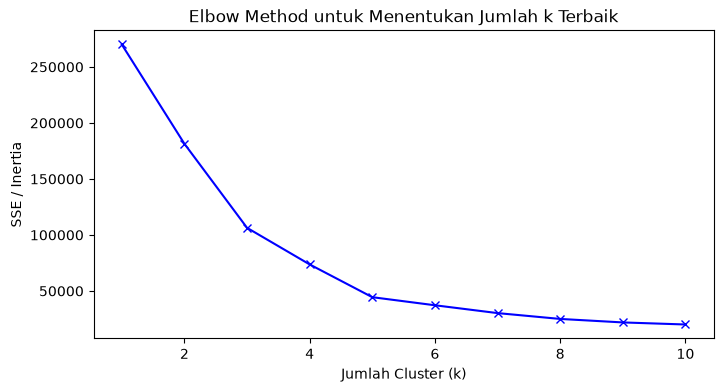

In [2]:
# Menganalisis nilai k terbaik menggunakan Elbow Method
sse = []
K = range(1, 11)

for k in K:
    kmeanModel = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeanModel.fit(X)
    sse.append(kmeanModel.inertia_)

# Visualisasi Elbow Plot
plt.figure(figsize=(8, 4))
plt.plot(K, sse, "bx-")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("SSE / Inertia")
plt.title("Elbow Method untuk Menentukan Jumlah k Terbaik")
plt.show()

c:\Users\M ALDYTH\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


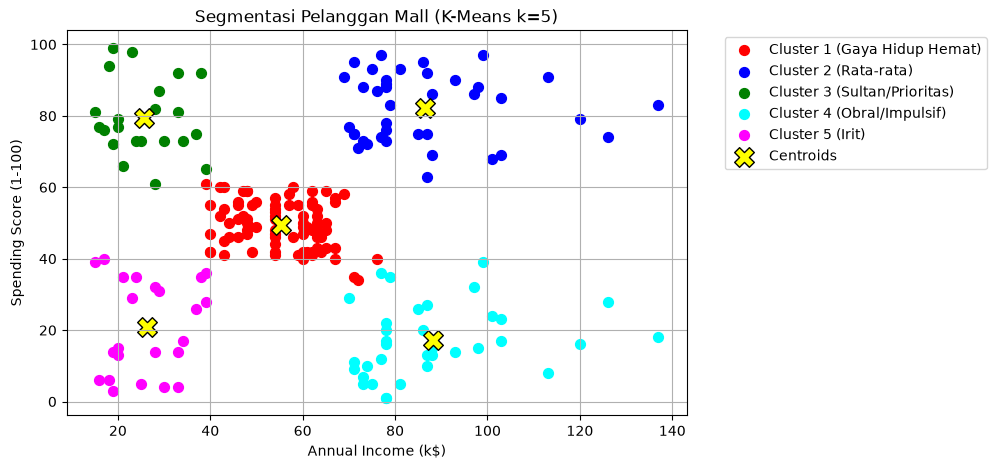

In [3]:
# Berdasarkan Elbow Plot, k=5 adalah titik siku (elbow point) paling optimal
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Visualisasi Hasil Clustering
plt.figure(figsize=(8, 5))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
labels = ['Cluster 1 (Gaya Hidup Hemat)', 'Cluster 2 (Rata-rata)', 'Cluster 3 (Sultan/Prioritas)', 'Cluster 4 (Obral/Impulsif)', 'Cluster 5 (Irit)']

for i in range(k_optimal):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=50, c=colors[i], label=labels[i])

# Plot Centroid
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='yellow', marker='X', edgecolors='black', label='Centroids')

plt.title('Segmentasi Pelanggan Mall (K-Means k=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

# Tugas 2: DBSCAN Clustering pada Dataset Make Moons

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

# 1. Buat dataset make_moons
X_moons, y_true = make_moons(n_samples=1000, noise=0.05, random_state=42)

# Normalisasi data
X_scaled = StandardScaler().fit_transform(X_moons)

In [5]:
from sklearn.cluster import DBSCAN
from sklearn import metrics

# 2. Jalankan DBSCAN (eps=0.2, min_samples=5)
db = DBSCAN(eps=0.2, min_samples=5).fit(X_scaled)
labels = db.labels_

# Hitung jumlah klaster dan noise
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"Jumlah Klaster : {n_clusters_}")
print(f"Jumlah Noise   : {n_noise_}\n")

# 3. Metrik Evaluasi
print("=== METRIK EVALUASI DBSCAN BASE ===")
print(f"Homogeneity                  : {metrics.homogeneity_score(y_true, labels):.3f}")
print(f"Completeness                 : {metrics.completeness_score(y_true, labels):.3f}")
print(f"V-measure                    : {metrics.v_measure_score(y_true, labels):.3f}")
print(f"Adjusted Rand Index (ARI)    : {metrics.adjusted_rand_score(y_true, labels):.3f}")
print(f"Adjusted Mutual Info (AMI)   : {metrics.adjusted_mutual_info_score(y_true, labels):.3f}")
print(f"Silhouette Coefficient       : {metrics.silhouette_score(X_scaled, labels):.3f}")

Jumlah Klaster : 2
Jumlah Noise   : 0

=== METRIK EVALUASI DBSCAN BASE ===
Homogeneity                  : 1.000
Completeness                 : 1.000
V-measure                    : 1.000
Adjusted Rand Index (ARI)    : 1.000
Adjusted Mutual Info (AMI)   : 1.000
Silhouette Coefficient       : 0.391


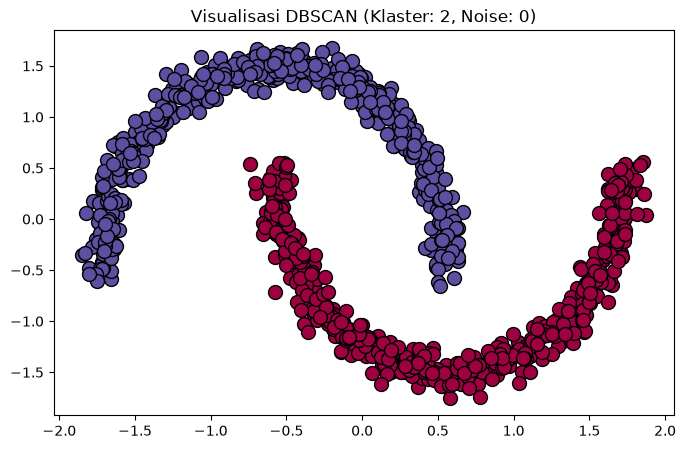

In [6]:
# 4. Visualisasi Hasil DBSCAN
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

plt.figure(figsize=(8, 5))
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # Warna hitam untuk noise

    class_member_mask = (labels == k)

    # Core sample (Titik Besar)
    xy = X_scaled[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=10)

    # Non-core sample (Titik Kecil)
    xy = X_scaled[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=4)

plt.title(f"Visualisasi DBSCAN (Klaster: {n_clusters_}, Noise: {n_noise_})")
plt.show()

In [7]:
# 5. Eksperimen kombinasi eps dan min_samples
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

results = []

for eps in eps_values:
    for min_s in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_s).fit(X_scaled)
        lbls = model.labels_
        
        n_c = len(set(lbls)) - (1 if -1 in lbls else 0)
        n_n = list(lbls).count(-1)
        
        # Hitung metrik evaluasi (jika cluster > 1)
        if n_c > 1:
            homo = metrics.homogeneity_score(y_true, lbls)
            comp = metrics.completeness_score(y_true, lbls)
            v_m = metrics.v_measure_score(y_true, lbls)
            ari = metrics.adjusted_rand_score(y_true, lbls)
            ami = metrics.adjusted_mutual_info_score(y_true, lbls)
            sil = metrics.silhouette_score(X_scaled, lbls)
        else:
            homo = comp = v_m = ari = ami = sil = np.nan

        results.append({
            'eps': eps,
            'min_samples': min_s,
            'clusters': n_c,
            'noise': n_n,
            'Homogeneity': round(homo, 3),
            'Completeness': round(comp, 3),
            'V-measure': round(v_m, 3),
            'ARI': round(ari, 3),
            'AMI': round(ami, 3),
            'Silhouette': round(sil, 3)
        })

# Tampilkan ringkasan eksperimen dalam DataFrame
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 eps  min_samples  clusters  noise  Homogeneity  Completeness  V-measure   ARI   AMI  Silhouette
0.05            3        69    186        0.816         0.153      0.257 0.030 0.244       0.113
0.05           10         3    970        0.031         0.127      0.049 0.002 0.046      -0.294
0.05           20         0   1000          NaN           NaN        NaN   NaN   NaN         NaN
0.10            3         2     14        0.986         0.903      0.943 0.972 0.943       0.252
0.10           10         7     57        0.943         0.410      0.571 0.523 0.570       0.162
0.10           20         6    850        0.154         0.155      0.155 0.017 0.151      -0.360
0.30            3         2      0        1.000         1.000      1.000 1.000 1.000       0.391
0.30           10         2      0        1.000         1.000      1.000 1.000 1.000       0.391
0.30           20         2      0        1.000         1.000      1.000 1.000 1.000       0.391
0.50            3         2   